In [1]:
import pandas as pd

def processingdata():
    df = pd.read_csv("../Dataset/healthcare-dataset-stroke-data.csv")
    mapping = {}
    cols = df.select_dtypes(include=["object"]).columns

    for col in df.columns:
        if col in cols:
            df[col] = df[col].fillna(df[col].mode()[0])
            uni_vals = df[col].unique()
            mpp = {val: i for i, val in enumerate(uni_vals)}
            df[col] = df[col].map(mpp)
            mapping[col] = mpp
        else:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df[col] = df[col].fillna(df[col].mean())

    return df, mapping

In [2]:
df, categorical_mappings = processingdata()
print(df)
print(categorical_mappings)

         id  gender   age  hypertension  heart_disease  ever_married  \
0      9046       0  67.0             0              1             0   
1     51676       1  61.0             0              0             0   
2     31112       0  80.0             0              1             0   
3     60182       1  49.0             0              0             0   
4      1665       1  79.0             1              0             0   
...     ...     ...   ...           ...            ...           ...   
5105  18234       1  80.0             1              0             0   
5106  44873       1  81.0             0              0             0   
5107  19723       1  35.0             0              0             0   
5108  37544       0  51.0             0              0             0   
5109  44679       1  44.0             0              0             0   

      work_type  Residence_type  avg_glucose_level        bmi  smoking_status  \
0             0               0             228.69  36

In [3]:

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

df = df.drop(columns=['id'], errors='ignore')

df['age'] = pd.cut(df['age'], bins=5, labels=False)
df['avg_glucose_level'] = pd.cut(df['avg_glucose_level'], bins=5, labels=False)
df['bmi'] = pd.cut(df['bmi'], bins=5, labels=False)

imputer = SimpleImputer(strategy='mean')
df.iloc[:, :] = imputer.fit_transform(df)

Prior Probabilities: {1: 0.5, 0: 0.5}


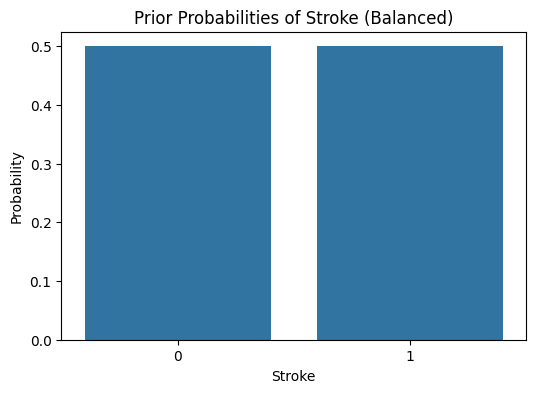

In [4]:
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

train_data, test_data = train_test_split(df, test_size=0.2, random_state=42, stratify=df['stroke'])
stroke_1 = train_data[train_data['stroke'] == 1].sample(n=100, random_state=42)
stroke_0 = train_data[train_data['stroke'] == 0].sample(n=100, random_state=42)
train_data = pd.concat([stroke_1, stroke_0], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

stroke_counts = Counter(train_data['stroke'])
total_samples = len(train_data)
prior_probabilities = {key: value / total_samples for key, value in stroke_counts.items()}
print("Prior Probabilities:", prior_probabilities)

plt.figure(figsize=(6, 4))
sns.barplot(x=list(prior_probabilities.keys()), y=list(prior_probabilities.values()))
plt.xlabel("Stroke")
plt.ylabel("Probability")
plt.title("Prior Probabilities of Stroke (Balanced)")
plt.show()

In [5]:
def calculate_laplace_likelihood(subset, feature):
    feature_counts = Counter(subset[feature])
    total_feature = len(subset) + len(df[feature].unique())
    return {key: (value + 1) / total_feature for key, value in feature_counts.items()}

laplace_likelihoods = {}
features = [col for col in df.columns if col != 'stroke']
for stroke_option in stroke_counts:
    laplace_likelihoods[stroke_option] = {}
    subset = train_data[train_data['stroke'] == stroke_option]
    for feature in features:
        laplace_likelihoods[stroke_option][feature] = calculate_laplace_likelihood(subset, feature)

In [6]:
import math

def calculate_posterior(test_row, threshold=0.6):
    log_posteriors = {}
    for stroke_option in prior_probabilities:
        log_posterior = math.log(prior_probabilities[stroke_option])
        for feature in features:
            feature_val = test_row[feature]
            likelihood_dict = laplace_likelihoods[stroke_option].get(feature, {})
            likelihood = likelihood_dict.get(feature_val, 1 / (len(train_data) + len(df[feature].unique())))
            log_posterior += math.log(likelihood)
        log_posteriors[stroke_option] = log_posterior

    max_log = max(log_posteriors.values())
    probs = {k: math.exp(v - max_log) for k, v in log_posteriors.items()}
    total_prob = sum(probs.values())
    normalized_probs = {k: v / total_prob for k, v in probs.items()}
    return 1 if normalized_probs.get(1, 0) >= threshold else 0


      stroke  Predicted_Stroke
3725       0                 1
4481       0                 0
1545       0                 0
1820       0                 0
1262       0                 1
...      ...               ...
1042       0                 0
1171       0                 0
3199       0                 0
3208       0                 0
1819       0                 1

[1022 rows x 2 columns]


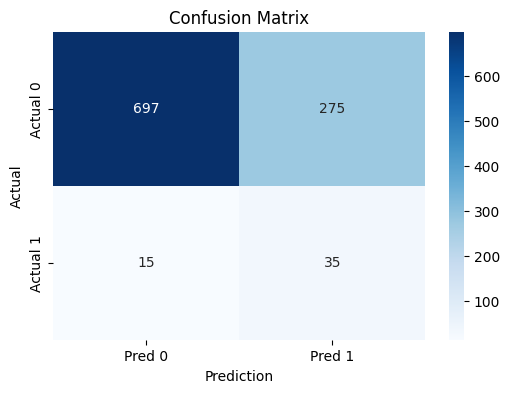

Accuracy: 0.7162

Classification Report:
              precision    recall  f1-score   support

   No Stroke     0.9789    0.7171    0.8278       972
      Stroke     0.1129    0.7000    0.1944        50

    accuracy                         0.7162      1022
   macro avg     0.5459    0.7085    0.5111      1022
weighted avg     0.9366    0.7162    0.7968      1022



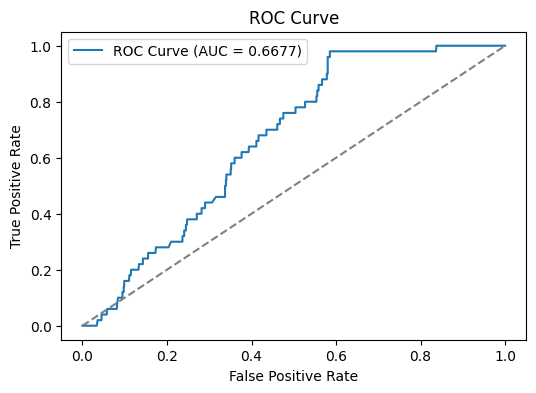

In [7]:

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score, roc_curve


test_data['Predicted_Stroke'] = test_data.apply(lambda row: calculate_posterior(row, threshold=0.6), axis=1)
print(test_data[['stroke', 'Predicted_Stroke']])

# Confusion matrix
conf_matrix = confusion_matrix(test_data['stroke'], test_data['Predicted_Stroke'])
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Accuracy
accuracy = accuracy_score(test_data['stroke'], test_data['Predicted_Stroke'])
print(f"Accuracy: {accuracy:.4f}")

# Classification report
report = classification_report(
    test_data['stroke'],
    test_data['Predicted_Stroke'],
    digits=4,
    zero_division=0,
    target_names=["No Stroke", "Stroke"]
)
print("\nClassification Report:")
print(report)

# ROC AUC curve
y_true = test_data['stroke']
y_scores = test_data.apply(lambda row: math.exp(
    math.log(prior_probabilities[1]) +
    sum(math.log(laplace_likelihoods[1][feature].get(row[feature], 1 / (len(train_data) + len(df[feature].unique()))))
        for feature in features)
), axis=1)
y_scores = (y_scores - y_scores.min()) / (y_scores.max() - y_scores.min())

fpr, tpr, _ = roc_curve(y_true, y_scores)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_true, y_scores):.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
